Load data and model

In [1]:
import pandas as pd
import pickle
import sys
sys.path.append("..")


df = pd.read_pickle("../data/features.pkl")
with open("../models/model_v1.pkl", "rb") as f:
    model = pickle.load(f)

Prepare the data

In [2]:
from python_editor.data_processing import split_by_developer, get_vectorized_features_and_label

train, test = split_by_developer(df, test_size=0.3, random_state=0)

In [3]:
from python_editor.feature_generation import FEATURES

X_test, y_test = get_vectorized_features_and_label(test, FEATURES)

Get predictions

In [4]:
y_pred = model.predict(X_test)

Residual analysis shows us:

1- Asymmetry in residuals (more extreme negatives than positives) which means the model is more often overpredicting than underpredicting.

2- Heteroscedasticity predictions around 5 is wide-spreaded and around higher values is narrow which means model is less certain in higher values

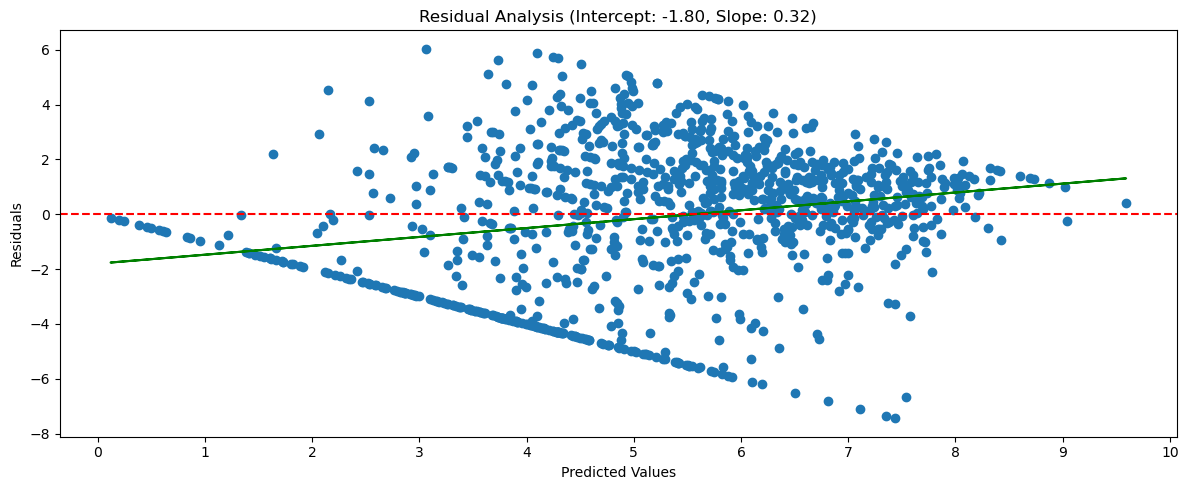

In [6]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

plt.scatter(y_pred, y_test-y_pred)
plt.axhline(y=0, color="r", linestyle="--")
plt.xticks(range(11))
plt.title("Residual Analysis")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [9]:
test.loc[:, "error"] = y_test - y_pred

/tmp/ipykernel_135938/4180407341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, "error"] = y_test - y_pred


We examine top performing, most over estimated and most under estimated examples

In [10]:
from python_editor.model_evaluation import get_top_k


top_performing, most_over_estimated, most_under_estimated = get_top_k(test, "error", 3)

to_display = [
    "pylint_score",
    "characters",
    "code_compactness",
    "chars_per_line",
    "comment_ratio",
    "has_docstring",
    "variable_ratio",
    "avg_var_name",
    "num_funcs_and_classes",
    "avg_func_class_name",
    "avg_func_class_chars",
    "avg_func_class_args",
    "func_class_docstring_ratio",
    "error"
]

Top performing examples have:

1- Average to low number of characters

2- Comments

In [12]:
top_performing[to_display]

,pylint_score,characters,code_compactness,chars_per_line,comment_ratio,has_docstring,variable_ratio,avg_var_name,num_funcs_and_classes,avg_func_class_name,avg_func_class_chars,avg_func_class_args,func_class_docstring_ratio,error
700,6.470588,2918.0,0.756303,24.521008,0.071282,1.0,0.004798,7.928571,4.0,6.750000,872.000000,1.250000,0.75,0.000581
2321,4.444444,363.0,1.000000,36.300000,0.195592,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00,0.001145
2421,6.292135,4825.0,0.881579,31.743421,0.168912,0.0,0.005596,6.037037,7.0,9.142857,258.142857,1.285714,0.00,0.004619


Overestimated examples have:

1- Average number of characters

2- Comments

3- Moderate average variable name

In [14]:
most_over_estimated[to_display]

,pylint_score,characters,code_compactness,chars_per_line,comment_ratio,has_docstring,variable_ratio,avg_var_name,num_funcs_and_classes,avg_func_class_name,avg_func_class_chars,avg_func_class_args,func_class_docstring_ratio,error
3341,0.0,2435.0,0.753425,33.356164,0.105544,1.0,0.002464,11.333333,2.0,8.500000,2127.000000,2.000000,0.500000,-7.437502
932,0.0,2134.0,0.657143,30.485714,0.009841,1.0,0.004217,9.222222,3.0,10.333333,885.000000,2.000000,0.333333,-7.355157
1370,0.0,4415.0,0.840336,37.100840,0.130464,0.0,0.001359,11.500000,9.0,10.555556,972.555556,2.111111,0.555556,-7.107510


Underestimated examples have: 

1- Very low or very high number of characters

2- Very low or very high characters per line

In [16]:
most_under_estimated[to_display]

,pylint_score,characters,code_compactness,chars_per_line,comment_ratio,has_docstring,variable_ratio,avg_var_name,num_funcs_and_classes,avg_func_class_name,avg_func_class_chars,avg_func_class_args,func_class_docstring_ratio,error
3366,9.100529,62236.0,0.889974,40.518229,0.057378,0.0,0.001334,13.746988,6.0,11.666667,10094.166667,0.5,0.0,6.035069
2470,10.000000,212.0,0.714286,15.142857,0.108491,1.0,0.018868,10.250000,0.0,0.000000,0.000000,0.0,0.0,5.899718
1649,10.000000,1185.0,0.944444,21.944444,0.008439,1.0,0.000844,4.000000,0.0,0.000000,0.000000,0.0,0.0,5.753911


Feature importance shows that the model relies on embeddings and generated features

In [18]:
from python_editor.model_evaluation import get_feature_importance


embedding_dim = test["embedding"][0].shape[0]

importance_df = get_feature_importance(model, embedding_dim, FEATURES)
importance_df.head(10)

,feature,importance
449,449,0.056639
137,137,0.019368
66,66,0.016122
773,variable_ratio,0.015037
318,318,0.012088
561,561,0.010978
672,672,0.009967
779,func_class_docstring_ratio,0.009590
244,244,0.009185
772,has_docstring,0.008160


In [19]:
X_train, y_train = get_vectorized_features_and_label(train, FEATURES)

Shapley values confirms that both embeddings and generated features are relevant. Here are a [video](https://youtu.be/NBg7YirBTN8?si=se9qccwpeFOoNLoF) that explains shapley values intutively and a [playlist](https://www.youtube.com/playlist?list=PLcrc6i6xwaQSw8553tgt1p8XOMFEdQCbl) that explains the maths behind it

 99%|===================| 1045/1060 [00:59<00:00]        

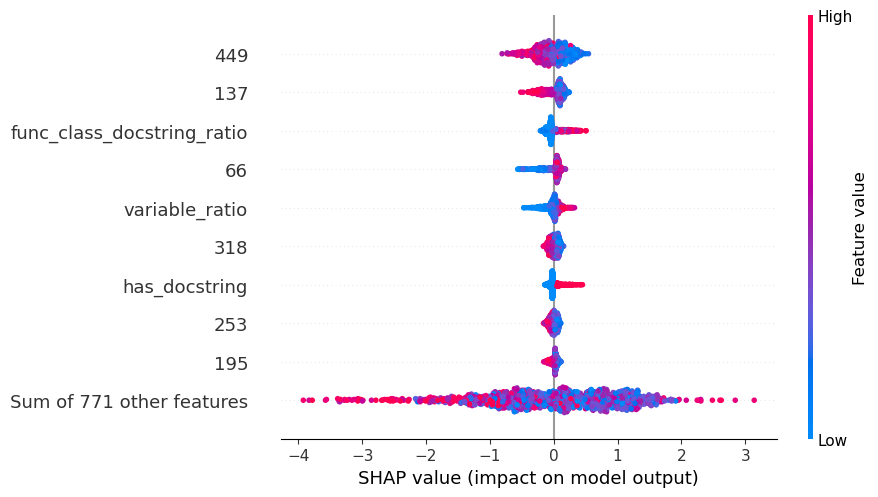

In [20]:
import shap
from python_editor.model_evaluation import get_shap_df
shap.initjs()

shap_values = get_shap_df(model, embedding_dim, FEATURES, X_train, X_test)
shap.plots.beeswarm(shap_values)